# 02 · Candidate signal at t₀ and t₁

What is worth feeding a model, and how much the carrier handover adds over what is already
known at approval.

> **Everything here runs on the training block only.** Looking at how a variable relates to the
> target in validation or test is choosing features with information from the blocks that are
> supposed to judge the result. No model is involved, and it is still leakage. In notebook 01
> the three blocks were compared on purpose — the job there was to *design* the split and that
> needs their sizes; the line is between knowing what test looks like and tuning anything to it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score

from src import config, data
from src.features import CATEGORICAL, T0_FEATURES, T1_FEATURES, load_features

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, BAND = "#0b0b0b", "#52514e", "#e8e8e6"
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 200,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "grid.color": BAND,
        "grid.linewidth": 0.8,
    }
)

features = load_features()
train = features[features["split"] == "train"]
base_rate = train["y"].mean()
print(f"{len(train):,} training orders · prevalence {base_rate:.2%}")

64,360 training orders · prevalence 14.70%


## 1 · Ranking the candidates

**Univariate AUC**: take one variable, use it directly as if it were the prediction, and
measure its ROC-AUC. It reads as *the probability that an order ending in a negative review
scores higher on this variable than one that does not*. 0.5 is knowing nothing; 1.0 is perfect
separation. It is the cheapest way to put variables of different scales in one table.

In [2]:
numeric = [c for c in T0_FEATURES + T1_FEATURES if c not in CATEGORICAL]

rows = []
for column in numeric:
    known = train[column].notna()
    values = train.loc[known, column].astype(float)
    auc = roc_auc_score(train.loc[known, "y"], values)
    rows.append(
        {
            "feature": column,
            "moment": "t1" if column in T1_FEATURES else "t0",
            "auc": auc,
            "strength": abs(auc - 0.5),
            "direction": "higher = worse" if auc > 0.5 else "higher = better",
        }
    )

ranking = pd.DataFrame(rows).sort_values("strength", ascending=False).reset_index(drop=True)
ranking.round(4)

,feature,moment,auc,strength,direction
0,freight_total,t0,0.5900,0.0900,higher = worse
1,handover_days,t1,0.5756,0.0756,higher = worse
2,handover_vs_limit_days,t1,0.5695,0.0695,higher = worse
3,elapsed_share,t1,0.5639,0.0639,higher = worse
4,n_items,t0,0.5540,0.0540,higher = worse
5,payment_value,t0,0.5498,0.0498,higher = worse
6,distance_km,t0,0.5436,0.0436,higher = worse
7,handover_late,t1,0.5435,0.0435,higher = worse
8,same_state,t0,0.4578,0.0422,higher = better
9,price_total,t0,0.5403,0.0403,higher = worse


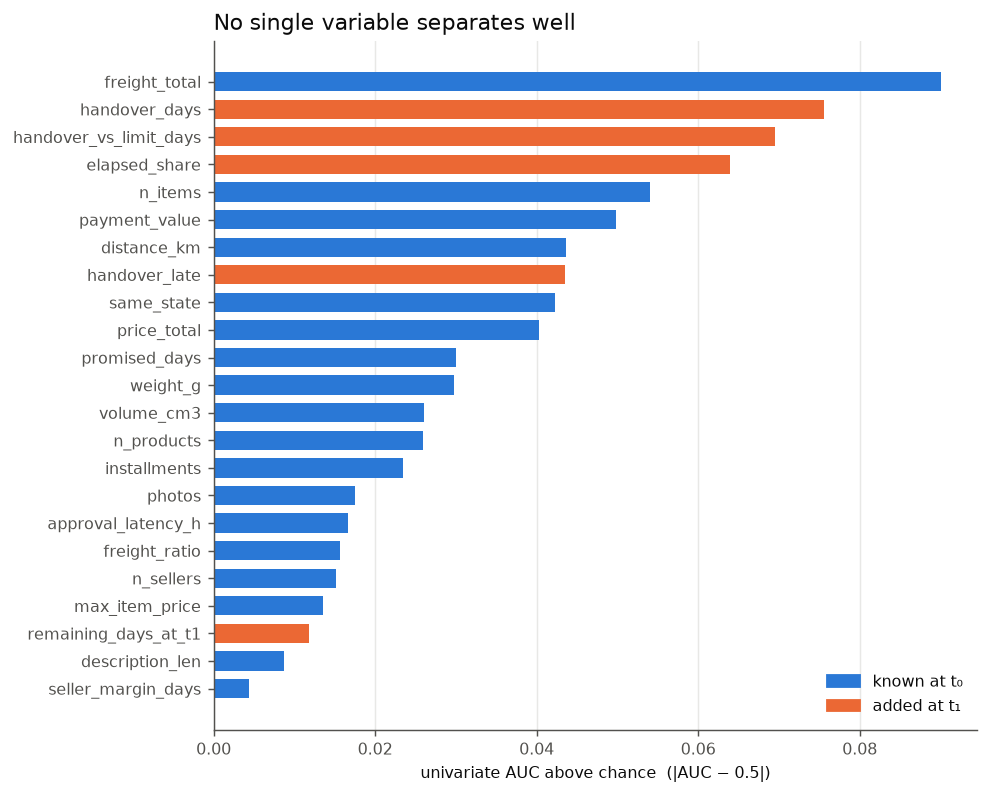

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 6), constrained_layout=True)
order = ranking.iloc[::-1]
colors = [ORANGE if m == "t1" else BLUE for m in order["moment"]]

ax.barh(order["feature"], order["strength"], color=colors, height=0.7)
ax.set_xlabel("univariate AUC above chance  (|AUC − 0.5|)")
ax.grid(axis="x")
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (BLUE, ORANGE)]
ax.legend(handles, ["known at t\u2080", "added at t\u2081"], frameon=False, loc="lower right")
ax.set_title("No single variable separates well", loc="left", fontsize=12)
fig.savefig(config.FIGURES / "univariate_signal.png", bbox_inches="tight")

The strongest single variable reaches an AUC of 0.59. That is a real finding, not a
disappointment: whatever value this project has will come from **combining** weak signals, and
any claim of a spectacular single predictor in this dataset should be treated as a leak.

## 2 · Two channels, not one

Notebook 01 showed the target tracks delivery delay. If that were the whole story, every useful
variable would predict lateness better than it predicts the review.

> **Leakage warning.** The next cell uses the actual delivery date to build a diagnostic
> `late` label. It is forbidden as a feature and `src/features.py` never touches it — there is
> a test that poisons the column and proves the feature matrix does not change.

In [4]:
delivery = data.load_table("orders")[
    ["order_id", "order_estimated_delivery_date", "order_delivered_customer_date"]
]
diag = train.merge(delivery, on="order_id", how="left")
diag["late"] = (
    diag["order_delivered_customer_date"] > diag["order_estimated_delivery_date"]
) | diag["order_delivered_customer_date"].isna()

channel = []
for column in numeric:
    known = diag[column].notna()
    values = diag.loc[known, column].astype(float)
    channel.append(
        {
            "feature": column,
            "vs_review": roc_auc_score(diag.loc[known, "y"], values),
            "vs_late": roc_auc_score(diag.loc[known, "late"], values),
        }
    )

channel = pd.DataFrame(channel)
channel["delay_channel"] = (channel["vs_late"] - 0.5).abs() - (channel["vs_review"] - 0.5).abs()
channel.sort_values("delay_channel", ascending=False).round(4)

,feature,vs_review,vs_late,delay_channel
21,remaining_days_at_t1,0.4881,0.4159,0.0722
19,handover_vs_limit_days,0.5695,0.6352,0.0657
22,elapsed_share,0.5639,0.6200,0.0561
18,handover_days,0.5756,0.6182,0.0426
3,distance_km,0.5436,0.5796,0.0360
20,handover_late,0.5435,0.5794,0.0359
1,approval_latency_h,0.5167,0.5458,0.0291
2,seller_margin_days,0.4956,0.4669,0.0288
4,same_state,0.4578,0.4321,0.0257
11,max_item_price,0.5136,0.5273,0.0137


Read the last column as *how much better this variable predicts a late delivery than it
predicts a bad review*.

- **Positive** — the variable works through delay: the handover timings, the distance.
- **Negative** — it predicts bad reviews through some other route. `n_items` is the clearest
  case: it carries signal about the review while being nearly useless about lateness. More
  items means more surface for something to go wrong — a wrong size, one item missing — and
  none of that is a logistics problem.

So reducing this to a delay model would throw away a real, separate channel.

## 3 · The shape of the relationships

An AUC cannot tell a straight line from a hockey stick, and the difference decides whether a
logistic regression can compete with a tree at all.

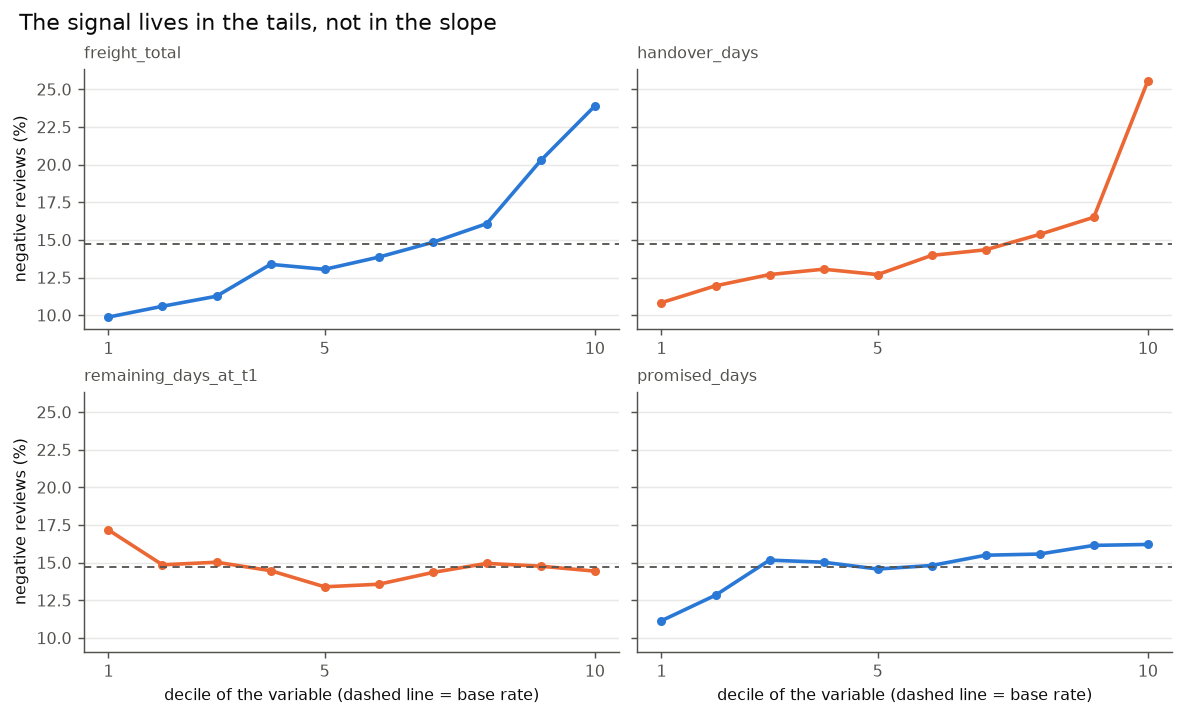

In [5]:
def prevalence_by_decile(frame, column, bins=10):
    deciles = pd.qcut(frame[column], bins, duplicates="drop")
    grouped = frame.groupby(deciles, observed=True)["y"].agg(["mean", "size"])
    return grouped.reset_index(drop=True)


shown = ["freight_total", "handover_days", "remaining_days_at_t1", "promised_days"]
fig, axes = plt.subplots(2, 2, figsize=(9, 5.4), constrained_layout=True, sharey=True)

for axis, column in zip(axes.ravel(), shown, strict=True):
    curve = prevalence_by_decile(train, column)
    colour = ORANGE if column in T1_FEATURES else BLUE
    axis.plot(
        range(1, len(curve) + 1),
        curve["mean"] * 100,
        color=colour,
        linewidth=2,
        marker="o",
        markersize=4,
    )
    axis.axhline(base_rate * 100, color=MUTED, linewidth=1, linestyle=(0, (4, 3)))
    axis.set_title(column, loc="left", fontsize=9, color=MUTED)
    axis.grid(axis="y")
    axis.set_axisbelow(True)
    axis.set_xticks([1, 5, 10])

axes[0][0].set_ylabel("negative reviews (%)")
axes[1][0].set_ylabel("negative reviews (%)")
for axis in axes[1]:
    axis.set_xlabel("decile of the variable (dashed line = base rate)")

fig.suptitle("The signal lives in the tails, not in the slope", fontsize=12, ha="left", x=0.01)
fig.savefig(config.FIGURES / "signal_shape.png", bbox_inches="tight")

`handover_days` is flat across nine deciles and then jumps to 25.6%. `remaining_days_at_t1`
only matters in its lowest decile — the orders leaving with no buffer left. That is the worst
possible shape for a raw logistic regression and the natural shape for a tree, which makes the
baseline comparison required by rule 5 an actual experiment rather than a formality.

## 4 · The categoricals

Two of them turn out to carry more than most of the numeric candidates.

In [6]:
def prevalence_by_level(frame, column, minimum=300):
    grouped = frame.groupby(column, observed=True)["y"].agg(["mean", "size"])
    grouped = grouped[grouped["size"] >= minimum].sort_values("mean")
    return grouped.assign(prevalence=lambda d: (d["mean"] * 100).round(1)).drop(columns="mean")


for column in ["customer_state", "product_category", "payment_type"]:
    levels = prevalence_by_level(train, column, minimum=500)
    print(
        f"--- {column}: {len(levels)} levels with 500+ orders "
        f"({levels['prevalence'].min():.1f}% .. {levels['prevalence'].max():.1f}%)"
    )
    # Only worth the ellipsis when there is something in the middle to hide.
    shown_levels = levels if len(levels) <= 6 else pd.concat([levels.head(3), levels.tail(3)])
    print(shown_levels.to_string(), end="\n\n")

--- customer_state: 15 levels with 500+ orders (11.7% .. 23.3%)
                 size  prevalence
customer_state                   
SP              25702        11.7
PR               3274        12.3
MG               7738        12.8
CE                915        21.7
RJ               8662        22.4
MA                536        23.3

--- product_category: 21 levels with 500+ orders (8.9% .. 23.4%)
                   size  prevalence
product_category                   
malas_acessorios    771         8.9
consoles_games      786        11.6
cool_stuff         2853        11.8
moveis_decoracao   4297        17.2
cama_mesa_banho    6296        17.6
moveis_escritorio   934        23.4

--- payment_type: 4 levels with 500+ orders (13.9% .. 15.2%)
               size  prevalence
payment_type                   
debit_card      661        13.9
boleto        13271        14.4
credit_card   49366        14.8
voucher        1062        15.2



## 5 · What this hands to the feature catalogue

1. **No single variable is strong.** Best univariate AUC 0.59. The model has to combine.
2. **Two channels.** Delay risk (handover timing, distance, promised buffer) and order
   complexity (item count, order value, category). Both are needed.
3. **Non-linear almost everywhere**, with the signal concentrated in the tails. Trees are
   favoured; a logistic baseline will need binned versions of the worst offenders to compete.
4. **Geography and category matter more than expected** — customer state spans 11.7% to 23.3%,
   category 8.9% to 23.4%. Both are high-cardinality categoricals, so encoding is a decision in
   its own right.
5. **Payment type carries nothing** (13.9% – 15.0%). It stays in the catalogue as a documented
   negative result rather than being quietly dropped.
6. **Still missing: seller history.** Every feature here describes the order. None describes
   the seller's track record — and a seller who was late on their last twenty orders is the
   obvious predictor. It needs a backward-looking window, which is the single easiest place in
   this project to leak, so it gets its own session.